### DSC 478 | Programming Machine Learning Applications | Spring 2026

#### Assignment-2 | Avni Sanghvi

---

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.preprocessing import StandardScaler

#### 1. Regression Analysis
#### For this problem you will experiment with multiple linear regression models to make predictions with numerical data. You will also explore more systematic methods for feature selection and for optimizing model hyperparameters (model selection). The data set you will use is a subset of the "Communities and Crime" data set that combines information from the 1990 census data as well as FBI crime data from 1995. Please read the full description of the data, including the description and statistics on different variables. The target attribute for regression purposes is "ViolentCrimesPerPop". Note: The two identifier attributes "state" and "community name" should be excluded for the regression task.

#### 1a. Load and preprocess the data using Pandas and remove the unneeded attributes. For the purpose of this assignment you do not need to normalize or standardize the data unless explicitly required in one of the following tasks. However, you may need to handle missing values by imputing those values based on variable means. Compute and display basic statistics (mean, standard deviation, min, max, etc.) for the variables in the data set. Separate the target attribute for regression. Use scikit-learn's train_test_split function to create a 20%-80% randomized split of the data (important note: for reproducible output across multiple runs, please use "random_state = 33"). Set aside the 20% test portion; the 80% training data partition will be used for cross-validation on various tasks specified below.

In [2]:
# Load the dataset
communities = pd.read_csv('communities.csv', na_values='?')

In [3]:
# shape of dataste
communities.shape

(1994, 100)

In [4]:
# view few rows of data
communities.head()

,state,communityname,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop
0,8,Lakewoodcity,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,...,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.20
1,53,Tukwilacity,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,...,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.67
2,24,Aberdeentown,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,...,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.43
3,34,Willingborotownship,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,...,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.12
4,42,Bethlehemtownship,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,...,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.03


In [5]:
# columns in the dataset
communities.columns

Index(['state', 'communityname', 'population', 'householdsize', 'racepctblack',
       'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21',
       'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban',
       'medIncome', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec',
       'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap',
       'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap',
       'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade',
       'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy',
       'PctEmplManu', 'PctEmplProfServ', 'MalePctDivorce', 'MalePctNevMarr',
       'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
       'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids',
       'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent',
       'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig',
       'PctRecImmig5', 'PctRecImmig8', 'P

In [6]:
# summary of the dataset
communities.describe()

,state,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,ViolentCrimesPerPop
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,28.683551,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,0.424218,0.493867,0.336264,...,0.022778,0.215552,0.608892,0.535050,0.626424,0.651530,0.065231,0.232854,0.161685,0.237979
std,16.397553,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,0.155196,0.143564,0.166505,...,0.100400,0.231134,0.204329,0.181352,0.200521,0.198221,0.109459,0.203092,0.229055,0.232985
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,0.010000,0.350000,0.020000,0.630000,0.040000,0.010000,0.340000,0.410000,0.250000,...,0.000000,0.060000,0.470000,0.420000,0.520000,0.560000,0.020000,0.100000,0.020000,0.070000
50%,34.000000,0.020000,0.440000,0.060000,0.850000,0.070000,0.040000,0.400000,0.480000,0.290000,...,0.000000,0.130000,0.630000,0.540000,0.670000,0.700000,0.040000,0.170000,0.070000,0.150000
75%,42.000000,0.050000,0.540000,0.230000,0.940000,0.170000,0.160000,0.470000,0.540000,0.360000,...,0.000000,0.280000,0.777500,0.660000,0.770000,0.790000,0.070000,0.280000,0.190000,0.330000
max,56.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# non predictive variables
cols_to_drop = ['state','communityname']

# dropping these non predictive variables
communities = communities.drop(columns=[col for col in cols_to_drop if col in communities.columns])

In [8]:
# value counts of each variable
for c in communities.columns:
    print(communities[c].value_counts())

population
0.01    454
0.00    385
0.02    271
0.03    193
0.04    121
       ... 
0.36      1
0.74      1
0.45      1
0.51      1
0.42      1
Name: count, Length: 66, dtype: int64
householdsize
0.41    76
0.39    69
0.35    68
0.37    67
0.33    65
        ..
0.03     1
0.91     1
0.85     1
0.08     1
0.82     1
Name: count, Length: 93, dtype: int64
racepctblack
0.01    285
0.02    236
0.03    141
0.00    134
0.04     86
       ... 
0.73      1
0.95      1
0.63      1
0.64      1
0.94      1
Name: count, Length: 100, dtype: int64
racePctWhite
0.98    122
0.96     99
0.97     96
0.99     82
0.95     81
       ... 
0.25      2
0.05      2
0.26      2
0.06      1
0.15      1
Name: count, Length: 99, dtype: int64
racePctAsian
0.02    191
0.03    175
0.04    168
0.05    144
0.06    121
       ... 
0.79      1
0.66      1
0.93      1
0.87      1
0.73      1
Name: count, Length: 91, dtype: int64
racePctHisp
0.01    446
0.02    254
0.03    158
0.04    124
0.05     95
       ... 
0.70      1


In [9]:
# imputing empty rows with mean values
num_cols = communities.select_dtypes(include=['number']).columns

communities[num_cols] = communities[num_cols].fillna(communities[num_cols].mean())

In [12]:
# separating the features
X = communities.drop(columns=['ViolentCrimesPerPop'])
y = communities['ViolentCrimesPerPop']

In [13]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=33)

In [14]:
print("x_train shape:", X_train.shape)
print("x_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1595, 97)
x_test shape: (399, 97)
y_train shape: (1595,)
y_test shape: (399,)


#### 1b. Perform standard multiple linear regression on data using the scikit-learn Linear Regression module. Compute the RMSE values on the full training data (the 80% partition). Also, plot the correlation between the predicted and actual values of the target attribute. Display the obtained regression coefficients (weights) and plot them using matplotlib. Finally, perform 10-fold cross-validation on the training partition and compare the cross-validation RMSE to the training RMSE (for cross validation, you should use the KFold module from sklearn.model_selection).

In [15]:
# Multiple Linear Regression
linreg = LinearRegression()

# Train the model using the training set
linreg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# prediction on training data by the model
p_train = linreg.predict(X_train)

# array of errors
err_train = abs(p_train - y_train)

# the sum of squared errors
sum_sq_err = np.dot(err_train,err_train)

# compute RMSE
rmse_train = np.sqrt(sum_sq_err/len(p_train))
print("RMSE on Training Data: ", rmse_train)

RMSE on Training Data:  0.12619593133426688


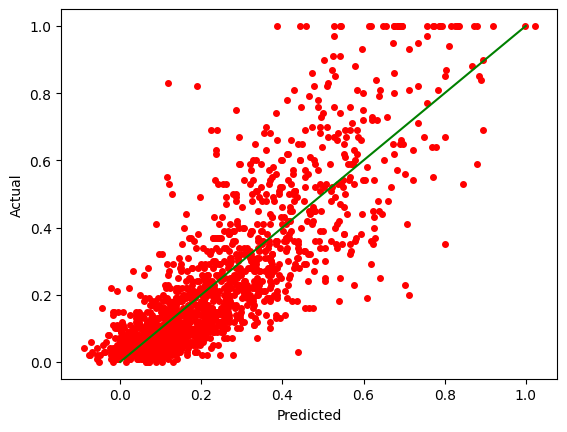

In [20]:
# Plot for predicted values against actual values (in the training data)
%matplotlib inline
plt.plot(p_train, y_train,'ro', markersize=4)
plt.plot([0,1],[0,1], 'g-')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [24]:
w = linreg.coef_
print(w)

[-7.52656629e-03 -5.28396680e-02  2.21547570e-01 -5.03199162e-02
 -1.96010315e-02  4.76949814e-02  1.02285177e-01 -1.69896511e-01
 -1.26211473e-01  7.14204649e-02 -1.25853261e-01  3.87986180e-02
 -2.01918099e-01 -2.13121910e-01  4.21246697e-02 -7.44445905e-02
  1.24852413e-02  2.25201184e-02 -9.58013048e-02  3.53979558e-01
  7.57326633e-02 -3.52089855e-01 -2.93676330e-02 -4.15893659e-02
  3.33220798e-02  4.71028688e-02  3.89021825e-02  2.97770808e-01
 -2.38551315e-01 -8.53275102e-03 -4.53960097e-02  7.67420267e-02
  1.56572032e-02  2.25051684e-01 -4.97873716e-02 -3.91366512e-02
  3.46194760e-01  2.11727329e-01  7.54492064e-02 -3.59121087e-01
 -1.58937159e-01 -1.73716203e-02 -2.60253644e-01 -4.63158082e-02
 -9.00374174e-03  8.91193223e-03 -1.57889829e-01 -2.66670112e-01
  1.43290159e-01 -1.18798830e-01  8.40395513e-03  4.89371965e-02
 -1.88835442e-01  1.36372557e-01 -3.22691120e-02 -2.44000729e-01
  6.40813099e-01 -3.81532245e-01 -3.50231164e-04 -1.47935514e-01
  5.34217081e-02 -2.16009

In [25]:
# Create a series where the index is the feature name and the value is the weight
feature_weights = pd.Series(w, index=X_train.columns)

# Print them to see the names against values
print(feature_weights)

population       -0.007527
householdsize    -0.052840
racepctblack      0.221548
racePctWhite     -0.050320
racePctAsian     -0.019601
                    ...   
PctSameCity85     0.041684
PctSameState85    0.015406
LandArea          0.019498
PopDens           0.000990
PctUsePubTrans   -0.042366
Length: 97, dtype: float64


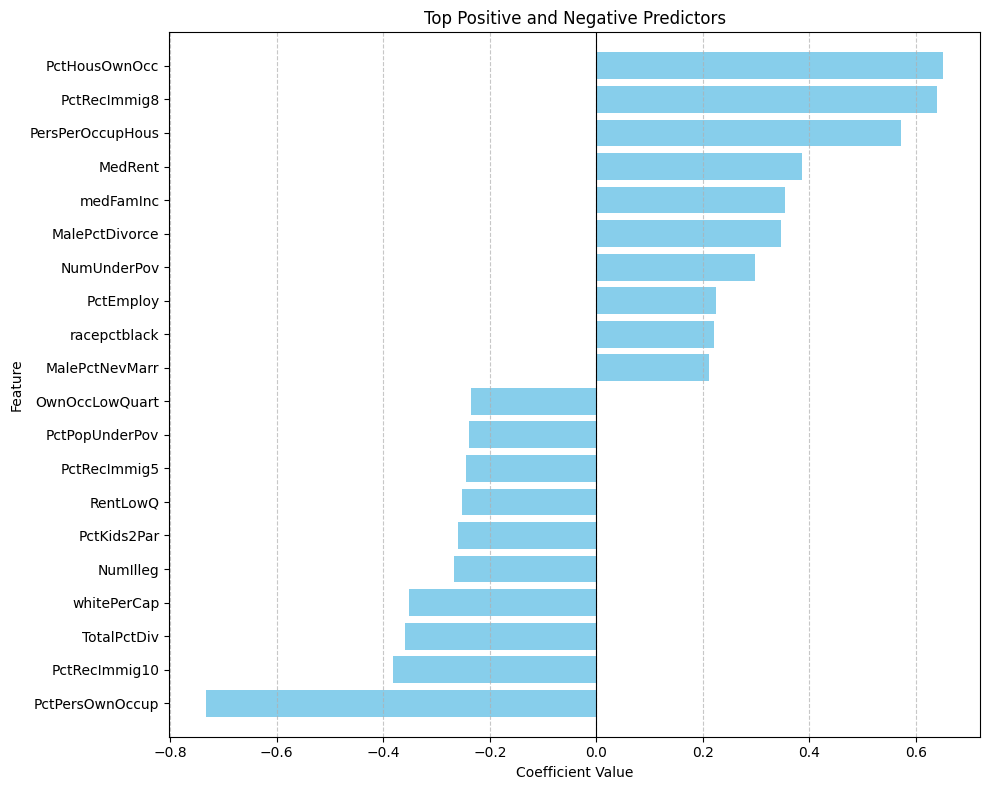

In [28]:
def plot_coefficients(model, feature_names):
    # Create a Series for easy sorting
    feat_importances = pd.Series(model.coef_, index=feature_names)
    
    # To keep the plot readable, let's look at the top 20 most influential features
    # (10 most positive and 10 most negative)
    top_and_bottom = pd.concat([
        feat_importances.sort_values().head(10),
        feat_importances.sort_values().tail(10)
    ])
    
    n_features = len(top_and_bottom)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    plt.barh(range(n_features), top_and_bottom.values, align='center', color='skyblue')
    plt.yticks(np.arange(n_features), top_and_bottom.index)
    
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.title("Top Positive and Negative Predictors")
    plt.ylim(-1, n_features)
    plt.axvline(0, color='black', lw=0.8) 
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_coefficients(linreg, X_train.columns)

In [33]:
def cross_validate(model, X, y, n, verbose=False):
    kf = KFold(n_splits=n, random_state=33, shuffle=True) 
                                        
    xval_err = 0
    f = 1
    
    for train_index, test_index in kf.split(X):
        X_train_kf, X_test_kf = X.iloc[train_index], X.iloc[test_index]
        y_train_kf, y_test_kf = y.iloc[train_index], y.iloc[test_index]
        
        # Fit and predict
        model.fit(X_train_kf, y_train_kf) 
        p_test = model.predict(X_test_kf) 
        
        # Calculate RMSE for the fold
        rmse_test = np.sqrt(mean_squared_error(y_test_kf, p_test))
        
        if verbose:
            print("Fold %2d RMSE: %.4f" % (f, rmse_test))
            
        xval_err += rmse_test
        f += 1
        
    return xval_err / n

In [34]:
# Compute Training RMSE (on the full training set)
linreg.fit(X_train, y_train)
p_train = linreg.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, p_train))

# Compute 10-fold Cross-Validation RMSE
rmse_10cv = cross_validate(linreg, X_train, y_train, 10, verbose=True)

Fold  1 RMSE: 0.1433
Fold  2 RMSE: 0.1425
Fold  3 RMSE: 0.1439
Fold  4 RMSE: 0.1210
Fold  5 RMSE: 0.1320
Fold  6 RMSE: 0.1669
Fold  7 RMSE: 0.1173
Fold  8 RMSE: 0.1442
Fold  9 RMSE: 0.1225
Fold 10 RMSE: 0.1124


In [35]:
#Comparison
print("\n" + "="*30)
print(f"Average 10-Fold CV RMSE: {rmse_10cv:.4f}")
print(f"Full Training RMSE:      {rmse_train:.4f}")
print(f"Difference:              {abs(rmse_10cv - rmse_train):.4f}")
print("="*30)


Average 10-Fold CV RMSE: 0.1346
Full Training RMSE:      0.1262
Difference:              0.0084


#### 1c. Feature Selection:  use the scikit-learn to select the best subset of features to perform linear regression. For feature selection, write a function that takes as input the training data; target variable; the regression model; and any other parameters you find necessary. The function should return the optimal percentage of the most informative features to use. Your approach should use k-fold cross-validation on the training data (use k=5 for consistency) and use feature_selection.SelectPercentile to find the most informative variables for a range of percentile values [Note: since this is regression not classification, in the SelectPercentile function you should use feature_selection.f_regression as scoring function rather than chi2). You should also plot the model's error values on cross-validation using only the selected features across the range of percentile values. You will use RMSE as the error metric. For cross-validation, use scikit's cross_val_score function. In order to use cross_val_score with regression you'll need to pass to it a specific error function. In this case, you will use scoring='neg_root_mean_squared_error' as a parameter. You should use absolute values to convert these negated RMSE values to positive RMSE values. Your plot should look similar to this example (which shows MAE values instead of RMSE values for a similar dataset). Once you have identified the best percentile based on cross-validation, use it to identify and display the corresponding best features. As a final step, train your model on the full 80% training data with the optimal subset of features and then compute its performance (again using RMSE) on the set-aside 20% test partition.

In [38]:
def find_optimal_features(model, X, y, k=5):
    percentiles = range(5, 101, 5)  
    results = []

    for p in percentiles:
        selector = SelectPercentile(score_func=f_regression, percentile=p)
        X_selected = selector.fit_transform(X, y)
        
        # Perform 5-fold Cross-Validation
        # We use neg_root_mean_squared_error; we must negate it to get positive RMSE
        scores = cross_val_score(model, X_selected, y, cv=k, scoring='neg_root_mean_squared_error')
        rmse_scores = np.abs(scores)
        results.append(rmse_scores.mean())

    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(percentiles, results, marker='o', linestyle='-', color='darkorange')
    plt.xlabel('Percentage of Features Selected')
    plt.ylabel('Cross-Validation RMSE')
    plt.title('Feature Selection: RMSE vs. Feature Percentile')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Identify the best percentile
    best_idx = np.argmin(results)
    optimal_p = percentiles[best_idx]
    print(f"Optimal Percentage of Features: {optimal_p}%")
    print(f"Minimum CV RMSE: {results[best_idx]:.4f}")
    
    return optimal_p

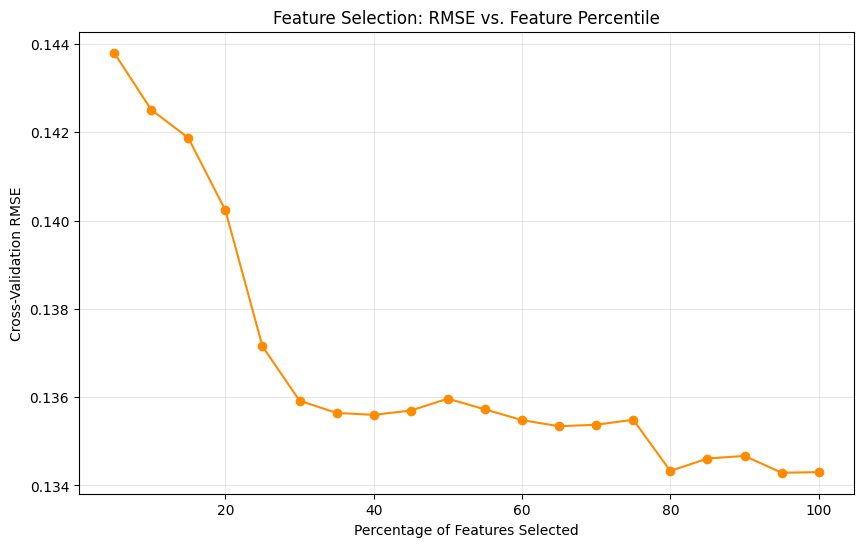

Optimal Percentage of Features: 95%
Minimum CV RMSE: 0.1343


In [39]:
optimal_percentile = find_optimal_features(linreg, X_train, y_train)

In [40]:
# Apply the optimal percentile to get the final feature mask
selector = SelectPercentile(score_func=f_regression, percentile=optimal_percentile)
selector.fit(X_train, y_train)

# Get the names of the selected features
best_features = X_train.columns[selector.get_support()]
print("\nSelected Features:")
print(list(best_features))

# Transform both training and test data to the optimal subset
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Final Model Training and Evaluation
linreg.fit(X_train_selected, y_train)
p_test = linreg.predict(X_test_selected)
final_test_rmse = np.sqrt(mean_squared_error(y_test, p_test))

print("\n" + "="*40)
print(f"Final RMSE on 20% Test Set (using top {optimal_percentile}% features): {final_test_rmse:.4f}")
print("="*40)


Selected Features:
['population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplProfServ', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup', 'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHou

#### 1d. Next, using the original train and test data in part (a), perform Ridge Regression and Lasso Regression using the modules from sklearn.linear_model. In each case, perform systematic model selection to identify the optimal alpha hyperparameter (the regularization coefficient). You should create a function that takes as input the training data and target variable; the parameter to vary and a list of its values; the model to be trained; and any other relevant input needed to determine the optimal value for the specified parameter. The model selection process should perform k-fold cross validation (k should be a parameter, but you can select k=5 for this problem). For each model, you should also plot the error values (again using RMSE as the error metric) on the training and cross-validation splits across the specified values of alpha. Finally, using the best alpha values for each regression model, train the model on the full training data and evaluate it on the set-aside test data. Discuss your observations and conclusions, especially about the impact of alpha on bias-variance trade-off. [Hint: for an example of a similar model optimization process in a classification task please review the class example notebook.]

In [45]:
def tune_alpha(X, y, model_class, alphas, k=5):
    train_rmse = []
    cv_rmse = []

    for a in alphas:
        # Initialize model with current alpha
        model = model_class(alpha=a)
        
        # Calculate Training RMSE (Full training partition)
        model.fit(X, y)
        p_train = model.predict(X)
        train_rmse.append(np.sqrt(mean_squared_error(y, p_train)))
        
        # Calculate Cross-Validation RMSE (Average of k-folds)
        # We use neg_root_mean_squared_error and convert to positive
        scores = cross_val_score(model, X, y, cv=k, scoring='neg_root_mean_squared_error')
        cv_rmse.append(np.abs(scores.mean()))

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(alphas, train_rmse, label='Training RMSE', marker='o')
    plt.plot(alphas, cv_rmse, label='Cross-Validation RMSE', marker='s')
    plt.xlabel('Alpha (Regularization Parameter)')
    plt.ylabel('RMSE')
    plt.title(f'Model Selection: {model_class.__name__} Alpha vs Error')
    plt.xscale('log') 
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find optimal alpha (index of minimum CV RMSE)
    best_alpha = alphas[np.argmin(cv_rmse)]
    print(f"Optimal Alpha for {model_class.__name__}: {best_alpha}")
    return best_alpha

# Define a range of alphas (usually powers of 10)
alpha_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

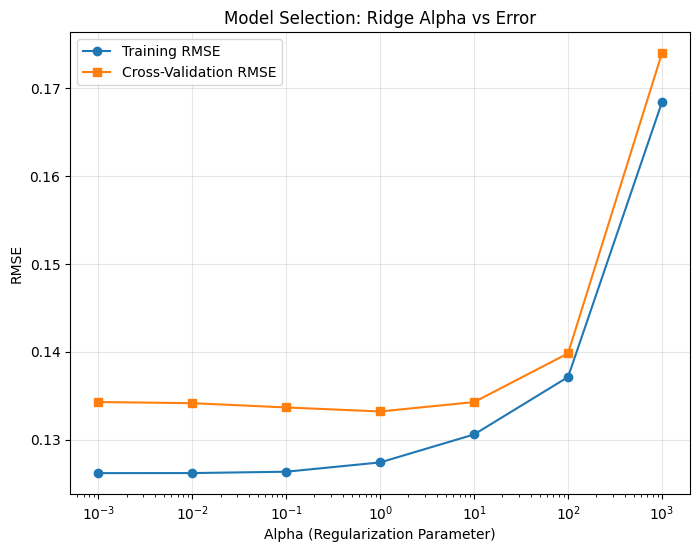

Optimal Alpha for Ridge: 1
Ridge Test RMSE: 0.1434


In [47]:
# Ridge Regularization
best_ridge_alpha = tune_alpha(X_train, y_train, Ridge, alpha_range)

# Final Evaluation
ridge_final = Ridge(alpha=best_ridge_alpha)
ridge_final.fit(X_train, y_train)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_final.predict(X_test)))
print(f"Ridge Test RMSE: {ridge_test_rmse:.4f}")

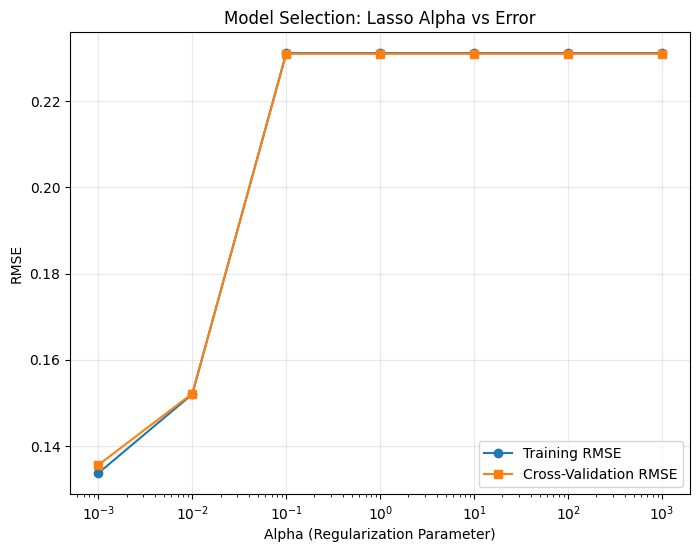

Optimal Alpha for Lasso: 0.001
Lasso Test RMSE: 0.1460


In [48]:
# Lasso Regularization
best_lasso_alpha = tune_alpha(X_train, y_train, Lasso, alpha_range)

# Final Evaluation
lasso_final = Lasso(alpha=best_lasso_alpha)
lasso_final.fit(X_train, y_train)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_final.predict(X_test)))
print(f"Lasso Test RMSE: {lasso_test_rmse:.4f}")

#### 1e. Next, perform regression using Stochastic Gradient Descent Regressor from scikit-learn (again use the original train-test split in part (a). Note that SGDRegessor requires that features be standardized (with 0 mean and scaled by standard deviation). Prior to fitting the model, perform the scaling using StandardScaler from sklearn.preprocessing. For this problem, perform a grid search (using GridSearchCV from sklearn.grid_search). Your grid search should compare combinations of two penalty parameters ('l2', 'l1') and different values of alpha (alpha could vary from 0.0001 which is the default to relatively large values, say 10). Using the best parameters, train the model on the full training partition and apply the model to the set-aside test data, comparing training and test RMSE scores. Finally, perform model optimization (similar to part d, above) to find the best "l1_ratio" parameter using SGDRegressor with the "elasticnet" penalty parameter. [Note: "l1_ratio" is The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1;  l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1 penalty; defaults to 0.15.] Using the best mixing ratio, apply the Elastic Net model, trained on full training data, to the set-aside test data and compare to the training performance. Provide a brief summary of your findings from the above experiments.

In [50]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2']
}

# Perform Grid Search
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=33)
grid_search = GridSearchCV(sgd, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

best_sgd = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Final Evaluation of Best SGD Model
p_train_sgd = best_sgd.predict(X_train_scaled)
p_test_sgd = best_sgd.predict(X_test_scaled)

print(f"SGD Training RMSE: {np.sqrt(mean_squared_error(y_train, p_train_sgd)):.4f}")
print(f"SGD Test RMSE:     {np.sqrt(mean_squared_error(y_test, p_test_sgd)):.4f}")

Best Parameters: {'alpha': 0.001, 'penalty': 'l1'}
SGD Training RMSE: 0.1320
SGD Test RMSE:     0.1468


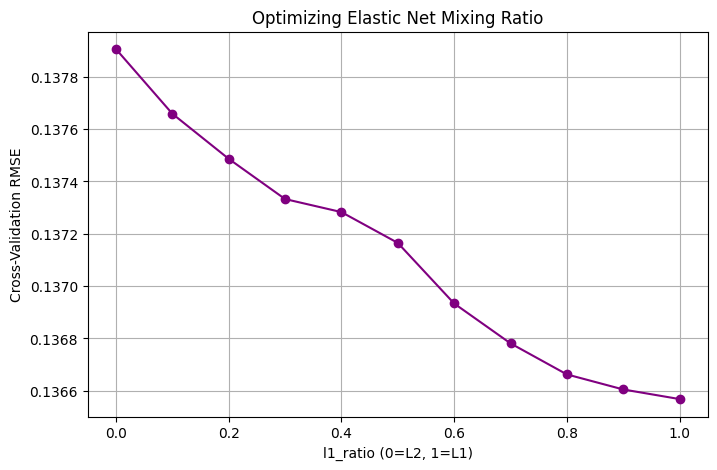

Optimal l1_ratio: 1.0
Elastic Net Test RMSE: 0.1468


In [51]:
def tune_elastic_net(X, y, alphas, l1_ratios, k=5):
    results = []
    
    for ratio in l1_ratios:
        # Using the best alpha found from grid search previously or a fixed alpha
        model = SGDRegressor(penalty='elasticnet', l1_ratio=ratio, alpha=grid_search.best_params_['alpha'], random_state=33)
        scores = cross_val_score(model, X, y, cv=k, scoring='neg_root_mean_squared_error')
        results.append(np.abs(scores.mean()))

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(l1_ratios, results, marker='o', color='purple')
    plt.xlabel('l1_ratio (0=L2, 1=L1)')
    plt.ylabel('Cross-Validation RMSE')
    plt.title('Optimizing Elastic Net Mixing Ratio')
    plt.grid(True)
    plt.show()

    best_ratio = l1_ratios[np.argmin(results)]
    print(f"Optimal l1_ratio: {best_ratio}")
    return best_ratio

l1_ratios = np.linspace(0, 1, 11) # [0.0, 0.1, ..., 1.0]
best_l1_ratio = tune_elastic_net(X_train_scaled, y_train, None, l1_ratios)

# Final Test Performance for Elastic Net
en_model = SGDRegressor(penalty='elasticnet', l1_ratio=best_l1_ratio, alpha=grid_search.best_params_['alpha'], random_state=33)
en_model.fit(X_train_scaled, y_train)
print(f"Elastic Net Test RMSE: {np.sqrt(mean_squared_error(y_test, en_model.predict(X_test_scaled))):.4f}")

#### 2. Document Clustering 
#### For this problem you will use a subset of the data from the BBC News Website. The data consists of 2,225 documents from the BBC news corresponding to stories in five topical categories from 2004-2005. The categories are: business, entertainment, politics, sport, and tech. The dataset for this assignment includes a document x term matrix based on 6,167 features used to represent the 2,225 documents. The entries in the matrix represent term frequencies for each term in each document. The dataset also includes the set of features, the class labels (category names) for each document, as well as the full textual data before preprocessing. Please review the README file in the archive for more details. The main task in this problem is to use an unsupervised clustering algorithm to cluster the documents, and then evaluate the results to see how closely the clusters capture the actual category assignments. 

#### 2a. Load the document x term matrix as well as the set of features and class labels into appropriate data structures. As in the previous assignment, create a plot of term frequencies across the whole dataset ranked from highest to lowest. Then use the train_test_split function (with random_state = 99) to perform a randomized split the data set (the document by term matrix) and set aside 20% for later use (see below). Use the 80% segment for clustering in the next part.

#### 2b. Perform Kmeans clustering on the training data from part (a) [Note: for this problem, use the proprietary implementation of the Kmeans clustering module provided in the file KMeans-2025.zip. Do not use the Scikit-learn Kmeans module.]  Display the cluster sizes as well as a data frame depicting the cluster centroid vectors. You can use the function provided in the K_Means.py module or create your own to display these results after clustering. Create your own function to display the documents in each cluster including document ids, document titles, and the original category name assigned to that document. The resulting output may look similar to this example.

#### 2c. Perform a qualitative analysis of the clusters by examining top features (terms) in each cluster and identifying patterns (e.g., top categories) captured in the clusters. To facilitate your analysis of the clusters, write a function to display the top N terms in each cluster sorted by decreasing centroid weights for each term in the cluster (mean frequency of the term in teh centroid). Your output should also display the cluster Document Frequency (DF) value for each of these the top N terms. The cluster DF value for a term t in a cluster C is the percentage of docs in cluster C in which term t appears (so, if a cluster has 500 documents, and term "game" appears in 100 of those 500 documents, then DF value of "game" in that cluster is 0.2 or 20%). For each cluster, you should also display the cluster size (the number of documents in the cluster). Here is an example of how this output might look like (here the top 10 terms for a sample of clusters are displayed in decreasing order of mean weights from the cluster centroids (the "Freq" column), but in addition the cluster DF values (both raw and as a percentage) are also shown).

#### Important Note: for this problem you should try several values of k for the number of clusters (try values of k from 4 through 8) and in each case try several runs in order to obtain clusters that seem more meaningful (note that for the same value of k, different runs may produce different clusters). In some cases, you may find some small clusters containing noise documents, which is not unusual. For higher values of k, you may also find the multiple clusters may capture similar patterns (such as documents from the same category). The point is to experiment with different runs and cluster numbers until you find at least several clusters that seem to capture some of the key topics in the documents. You also want to avoid documents that should belong to the same group being split across multiple clusters. You do not need to provide the results of all your runs; you should only provide the results of your best clustering along with a brief discussion of your experimentation and your final observations. [Note: this discussion is required to obtain full credit on this problem].
 
#### [Extra Credit - 5 pts: use your favorite third party tool or library to create a word cloud for each cluster (using your best clustering from earlier experiments.]

#### 2d. Rerun Kmeans on the data using K=5. Using the cluster assignments from your Kmeans clustering and the original category labels assigned to the documents, compare your clusters to the classes by computing the Completeness and Homogeneity scores. The goal is to determine the degree to which automatic clustering can capture the original pre-defined categories in the data. First perform Silhouette analysis on the clusters (compute Silhouette values for all instances in the data, and then compute the overall mean Silhouette value; then provide a visualization of the Silhouettes in a similar manner as in the class examples). Next, compare your 5 clusters to the 5 pre-assigned classes by computing the Completeness and Homogeneity values of the generated clusters.

#### 2e. Finally, using your cluster assignments as class labels, categorize each of the documents in the 20% set-aside data into the appropriate clusters (using your final clustering results in part b). Your categorization should be based on Cosine similarity between each test document and cluster centroids. For each test document show the document id, document title, the assigned cluster label, and the Cosine similarity to the corresponding cluster [Note: perform this categorization task on all test documents, but for the purpose of the assignment, please only submit the results for the results for the first 10 test documents].